<a href="https://colab.research.google.com/github/90splayer/AI-HEALTH-LAB/blob/main/week_9_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

# Data from CIFAR10

In [1]:
# Chibuzor Ojogbo
import tensorflow as tf
from keras.datasets import cifar10
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
from skimage import color
import pandas as pd
import numpy as np
from copy import deepcopy
import random
from sklearn.metrics import mean_squared_error

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 435s 3us/step


(32, 32)

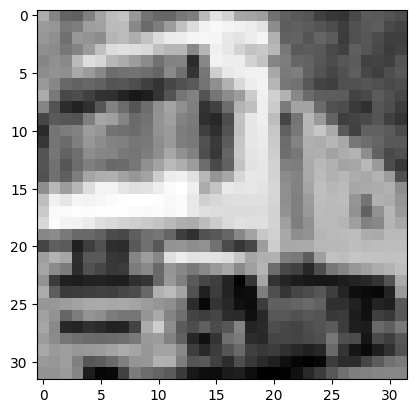

In [2]:
# loading data from cifar
(X_train, y_train) , (X_test, y_test) = cifar10.load_data()

#select one image
img = color.rgb2gray(X_train[1])
plt.imshow(img,cmap=plt.cm.gray)
img.shape

# Dropping missing values randomly

In [3]:
def generate_Missing_Images(Org,P,S):
# this function generates Images with missing values given Org = orinigal image and P = missing percentage, S= size of image
    Mask = np.zeros((S, S))
    out = deepcopy(Org)
    Missingnumbers = int(P * S*S)
    for i in range(Missingnumbers):
        index1 = random.randint(0,S-1)
        index2 = random.randint(0,S-1)
        out[index1,index2] = np.nan
        Mask[index1,index2] = 0
    return out

In [4]:
# we can define the rate of missingness
missingPercentage = 0.3
missing_image = generate_Missing_Images(img,missingPercentage,32) # 32 is the size of image in cifar
dataframe_image = pd.DataFrame(missing_image)


# Baseline Imputation models

# Simple Imputer

In [6]:
from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
imp_mean.fit(dataframe_image)
imputed_mean = imp_mean.transform(dataframe_image)
#difference between real image and imputed version
np.sqrt(mean_squared_error(img,imputed_mean))

np.float64(0.11910382972755024)

In [ ]:
#Repeat for median, constant and most_frequent here



In [ ]:
#consider different missing rates and repeate the experiments

# KNN


In [8]:
# KNN
from sklearn.impute import KNNImputer
# calling the KNN class
knn_imputer = KNNImputer(n_neighbors=2)
knn_imputer.fit(dataframe_image)
# imputing the missing value with knn imputer
Imputed_KNN = knn_imputer.transform(dataframe_image)
np.sqrt(mean_squared_error(img,Imputed_KNN))

np.float64(0.06607836308541215)

# Iterative Imputer

In [10]:
from sklearn.experimental import enable_iterative_imputer  # noqa
# now you can import normally from sklearn.impute
from sklearn.impute import IterativeImputer
imp_itr = IterativeImputer(random_state=0)
Imputed_itr = imp_itr.fit_transform(dataframe_image)
np.sqrt(mean_squared_error(img,Imputed_itr))

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


np.float64(0.059757541043430375)

# Missing indicator

In [11]:
from sklearn.impute import MissingIndicator
indicator = MissingIndicator()
indicator.fit(dataframe_image)
X2_tr = indicator.transform(dataframe_image)
X2_tr
# Chibuzor Ojogbo

array([[False, False, False, ..., False, False,  True],
       [False, False, False, ..., False, False, False],
       [False,  True,  True, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False,  True],
       [False,  True, False, ..., False,  True, False],
       [False,  True, False, ..., False,  True, False]])

# Useful Python Libraries for Data Imputation

Source: https://pypi.org/project/missingpy/

Source: https://pypi.org/project/fancyimpute/

Sourse: https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html#sklearn.impute.SimpleImputer